# Feature Engineering EDA — Demand Intelligence Pipeline

**Goal:** Reduce the feature matrix before XGBoost training by:
1. **Row-level activity filter** — at each `year_month` T, drop the row if the outlet-item had
   zero demand in the 6 months *before* T (i.e. `demand_event_rate_6m == 0`).  
   This removes sparse, dormant rows across the full time series, not just at the dataset tail.
2. **Correlation filter** — remove features with |r| ≥ 0.90 (greedy elimination).
3. **Save** reduced versions of each source table for downstream modelling.

Dataset joins follow `docs/11_feature_merging_guide.md`.

---
## 1. Setup & Imports

In [16]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

INTERMEDIATE_DIR = Path('../../data/Intermediate')
OUTPUT_DIR       = INTERMEDIATE_DIR

CORR_THRESHOLD = 0.8   # drop one feature if |r| >= this
SAMPLE_OUTLETS = 800    # outlet_ids used for EDA sample (~memory budget knob)
RANDOM_SEED    = 42

print('Polars version :', pl.__version__)
print('Data dir exists:', INTERMEDIATE_DIR.exists())

Polars version : 1.40.1
Data dir exists: True


---
## 2. Schema Overview

In [2]:
lf_base     = pl.scan_parquet(INTERMEDIATE_DIR / 'base_features_for_modeling.parquet')
lf_zero     = pl.scan_parquet(INTERMEDIATE_DIR / 'zero_inflation_features.parquet')
lf_target   = pl.scan_parquet(INTERMEDIATE_DIR / 'target_features.parquet')
lf_sku      = pl.scan_parquet(INTERMEDIATE_DIR / 'enriched_sku_lookup.parquet')
lf_seasonal = pl.scan_parquet(INTERMEDIATE_DIR / 'seasonal_index_lookup.parquet')

frames = {
    'base_features_for_modeling':  lf_base,
    'zero_inflation_features':      lf_zero,
    'target_features':              lf_target,
    'enriched_sku_lookup':          lf_sku,
    'seasonal_index_lookup':        lf_seasonal,
}

for name, lf in frames.items():
    schema = lf.schema
    print(f'\n=== {name}  ({len(schema)} columns) ===')
    for col, dtype in schema.items():
        print(f'  {col:<46} {dtype}')


=== base_features_for_modeling  (64 columns) ===
  outlet_id                                      String
  item_code                                      String
  year_month                                     String
  net_quantity                                   Int64
  net_sales                                      Float64
  gross_quantity                                 Int64
  gross_sales                                    Float64
  return_quantity                                Int64
  return_sales                                   Float64
  n_invoices                                     UInt32
  n_returns                                      UInt32
  territory_id                                   String
  region                                         String
  district                                       String
  province                                       String
  product_category                               String
  product_line                                   Strin

---
## 3. Row-Level Activity Filter

**Logic:**  
At each row `(outlet_id, item_code, year_month = T)`, we keep the row only if:
```
demand_event_rate_6m > 0
```
`demand_event_rate_6m` is the fraction of months in `[T−6, T−1]` where `net_quantity > 0`.  
A value of 0 means **no sales in the prior 6 months** — the row is dormant and dropped.

**Example:** row at 2018-01 → checks 2017-07 to 2017-12. If all zero, row is removed.

In [3]:
JOIN_KEYS = ['outlet_id', 'item_code', 'year_month']

# Row counts before filtering (report from parquet metadata — no full scan)
n_before = lf_base.select(pl.len()).collect().item()
print(f'Rows in base before filter: {n_before:,}')

Rows in base before filter: 100,618,320


In [4]:
# Build the activity-filtered lazy frame:
#   join base + zero_inflation, keep rows with demand_event_rate_6m > 0

lf_base_active = (
    lf_base
    .join(
        lf_zero.select(JOIN_KEYS + ['demand_event_rate_6m']),
        on=JOIN_KEYS,
        how='left'
    )
    .filter(pl.col('demand_event_rate_6m') > 0)
    .drop('demand_event_rate_6m')   # already present in lf_zero; drop the joined copy
)

n_after = lf_base_active.select(pl.len()).collect().item()
print(f'Rows after activity filter  : {n_after:,}')
print(f'Rows removed                : {n_before - n_after:,}  ({(n_before - n_after)/n_before:.1%})')

Rows after activity filter  : 23,442,722
Rows removed                : 77,175,598  (76.7%)


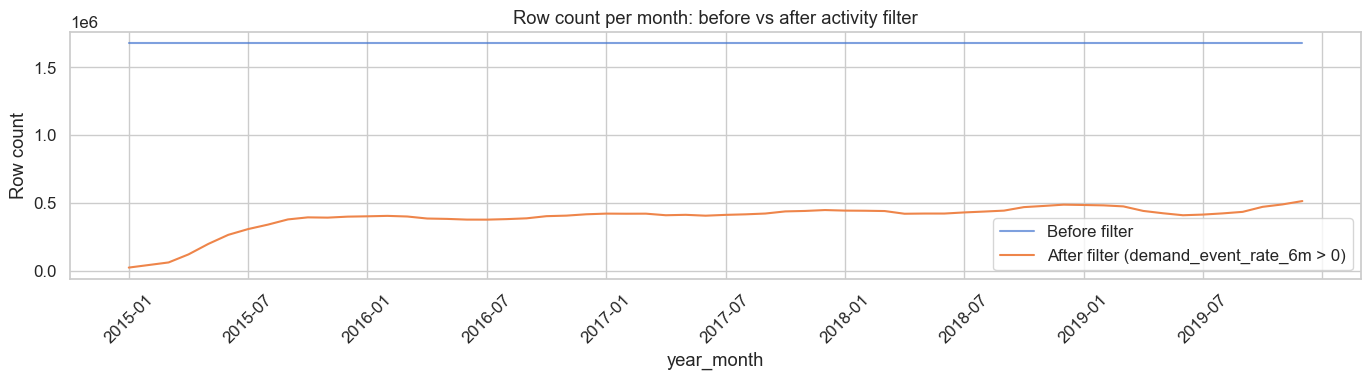

In [5]:
# Visualise filter impact by year_month
rows_by_month_before = (
    lf_base
    .group_by('year_month')
    .agg(pl.len().alias('n_rows'))
    .collect()
    .sort('year_month')
)

rows_by_month_after = (
    lf_base_active
    .group_by('year_month')
    .agg(pl.len().alias('n_rows'))
    .collect()
    .sort('year_month')
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rows_by_month_before['year_month'].to_list(),
        rows_by_month_before['n_rows'].to_list(),
        label='Before filter', alpha=0.7, linewidth=1.5)
ax.plot(rows_by_month_after['year_month'].to_list(),
        rows_by_month_after['n_rows'].to_list(),
        label='After filter (demand_event_rate_6m > 0)', linewidth=1.5)
ax.set_xlabel('year_month')
ax.set_ylabel('Row count')
ax.set_title('Row count per month: before vs after activity filter')
ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Build & Sample the Filtered Modeling Matrix

For correlation analysis we collect a **memory-safe sample**: randomly select `SAMPLE_OUTLETS`
outlet IDs and load all their rows.  The full filtered data stays lazy for the final write step.

In [6]:
# Full lazy modeling matrix (filtered), mirrors docs/11_feature_merging_guide.md
lf_matrix = (
    lf_base_active
    .join(lf_zero,     on=JOIN_KEYS,                   how='left')
    .join(lf_target,   on=JOIN_KEYS,                   how='left')
    .join(lf_sku,      on='item_code',                 how='left')
    .join(lf_seasonal, on=['item_code', 'month_int'],  how='left')
)

print('Lazy matrix ready. Total columns:', len(lf_matrix.schema))

Lazy matrix ready. Total columns: 80


In [7]:
# Sample SAMPLE_OUTLETS outlet_ids for EDA
all_outlets = lf_base_active.select('outlet_id').unique().collect()['outlet_id'].to_list()

rng = np.random.default_rng(RANDOM_SEED)
sampled_outlets = rng.choice(all_outlets,
                             size=min(SAMPLE_OUTLETS, len(all_outlets)),
                             replace=False).tolist()

print(f'Total active outlets   : {len(all_outlets):,}')
print(f'Outlets in EDA sample  : {len(sampled_outlets):,}')

sample_df = (
    lf_matrix
    .filter(pl.col('outlet_id').is_in(sampled_outlets))
    .collect()
)

print(f'Sample rows collected  : {sample_df.shape[0]:,}')
print(f'Sample columns         : {sample_df.shape[1]}')

Total active outlets   : 66,341
Outlets in EDA sample  : 800
Sample rows collected  : 280,049
Sample columns         : 80


---
## 5. Null Analysis

In [8]:
null_pct = (
    sample_df.null_count()
    .unpivot(variable_name='column', value_name='null_count')
    .with_columns((pl.col('null_count') / len(sample_df) * 100).alias('null_pct'))
    .sort('null_pct', descending=True)
    .filter(pl.col('null_pct') > 0)
)

print(f'Columns with any nulls: {null_pct.shape[0]}')
if null_pct.shape[0]:
    print(null_pct.to_pandas().to_string(index=False))

Columns with any nulls: 23
                column  null_count  null_pct
           lag_qty_12m       35869 12.808116
         lag_sales_12m       35869 12.808116
            yoy_growth       35869 12.808116
        target_qty_raw       12059  4.306032
      target_qty_log1p       12059  4.306032
     target_is_nonzero       12059  4.306032
target_log1p_net_sales       12059  4.306032
            lag_qty_6m        8638  3.084460
          lag_sales_6m        8638  3.084460
    trend_slope_approx        8638  3.084460
            lag_qty_3m        1406  0.502055
          lag_sales_3m        1406  0.502055
            lag_qty_2m         703  0.251027
          lag_sales_2m         703  0.251027
            lag_qty_1m         238  0.084985
          lag_sales_1m         238  0.084985
       roll_std_qty_3m         238  0.084985
       roll_std_qty_6m         238  0.084985
      roll_std_qty_12m         238  0.084985
     roll_std_sales_6m         238  0.084985
        roll_cv_qty_3m      

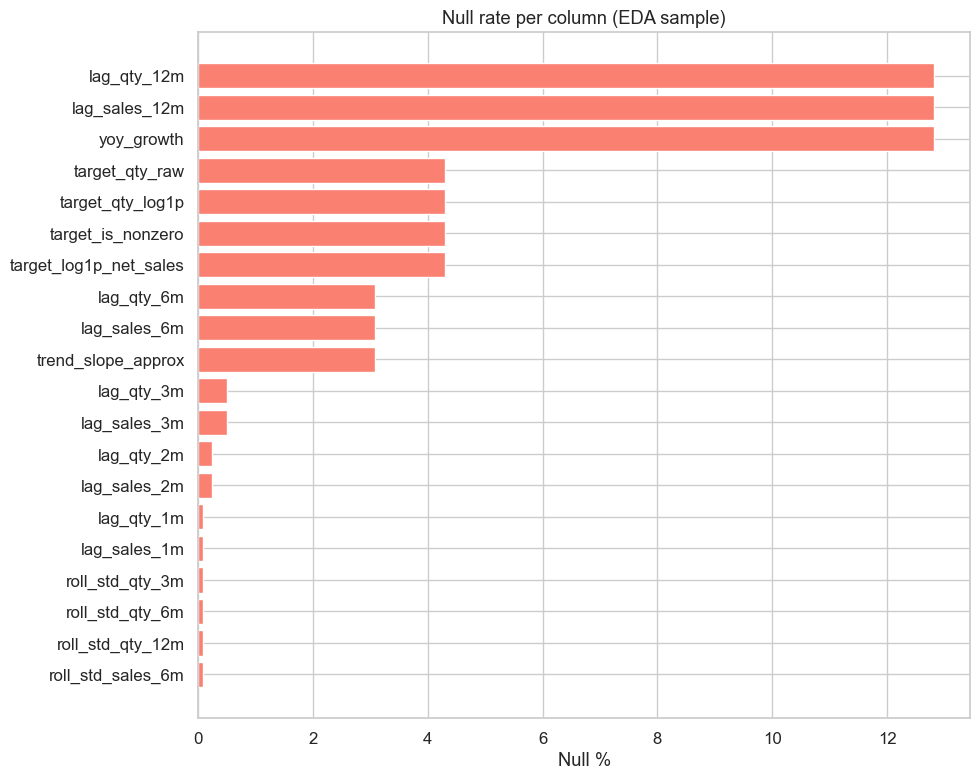

In [9]:
if null_pct.shape[0] > 0:
    top = null_pct.head(20)
    fig, ax = plt.subplots(figsize=(10, max(4, len(top) * 0.4)))
    ax.barh(top['column'].to_list()[::-1], top['null_pct'].to_list()[::-1], color='salmon')
    ax.set_xlabel('Null %')
    ax.set_title('Null rate per column (EDA sample)')
    plt.tight_layout()
    plt.show()

---
## 6. Correlation Analysis

Pearson correlations are computed on numeric feature columns only.  
Excluded: identifiers, categorical strings, target labels, and any column with >50 % nulls.

In [10]:
ID_COLS     = ['outlet_id', 'item_code', 'year_month']
CAT_COLS    = ['territory_id', 'region', 'district', 'province',
               'product_category', 'product_line', 'brand',
               'cluster_definition', 'demand_class']
TARGET_COLS = ['target_qty_raw', 'target_qty_log1p',
               'target_is_nonzero', 'target_log1p_net_sales']

EXCLUDE = set(ID_COLS + CAT_COLS + TARGET_COLS)

NUMERIC = {
    pl.Float32, pl.Float64,
    pl.Int8,  pl.Int16,  pl.Int32,  pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
}

feature_cols = [
    c for c, dtype in sample_df.schema.items()
    if c not in EXCLUDE and type(dtype) in NUMERIC
]

# Drop high-null columns (>50 % in sample)
null_rates_dict = (
    sample_df.select(feature_cols).null_count().row(0, named=True)
)
high_null = [c for c in feature_cols
             if (null_rates_dict[c] / len(sample_df)) > 0.50]
feature_cols = [c for c in feature_cols if c not in high_null]

print(f'Feature columns for correlation: {len(feature_cols)}')
if high_null:
    print(f'Excluded (>50 % null): {high_null}')
print()
for c in feature_cols:
    print(f'  {c}')

Feature columns for correlation: 64

  net_quantity
  net_sales
  gross_quantity
  gross_sales
  return_quantity
  return_sales
  n_invoices
  n_returns
  year
  month_int
  months_elapsed
  sin_1
  cos_1
  sin_2
  cos_2
  sin_3
  cos_3
  is_peak_month
  is_trough_month
  lag_qty_1m
  lag_qty_2m
  lag_qty_3m
  lag_qty_6m
  lag_qty_12m
  lag_sales_1m
  lag_sales_2m
  lag_sales_3m
  lag_sales_6m
  lag_sales_12m
  roll_mean_qty_3m
  roll_mean_qty_6m
  roll_mean_qty_12m
  roll_std_qty_3m
  roll_std_qty_6m
  roll_std_qty_12m
  roll_mean_sales_3m
  roll_mean_sales_6m
  roll_mean_sales_12m
  roll_std_sales_6m
  roll_nonzero_count_3m
  roll_nonzero_count_6m
  roll_nonzero_count_12m
  roll_cv_qty_3m
  roll_cv_qty_6m
  roll_cv_qty_12m
  yoy_growth
  momentum_ratio
  short_long_ratio
  trend_slope_approx
  current_return_rate
  roll_return_rate_3m
  roll_return_rate_6m
  price_per_unit
  months_since_last_purchase
  consecutive_zeros
  demand_event_rate_6m
  demand_event_rate_12m
  demand_class_e

In [11]:
# Build correlation matrix (fill nulls with per-column median first)
feat_pdf = sample_df.select(feature_cols).to_pandas()
feat_pdf = feat_pdf.fillna(feat_pdf.median(numeric_only=True))

corr_matrix = feat_pdf.corr(method='pearson')
print(f'Correlation matrix: {corr_matrix.shape}')

Correlation matrix: (64, 64)


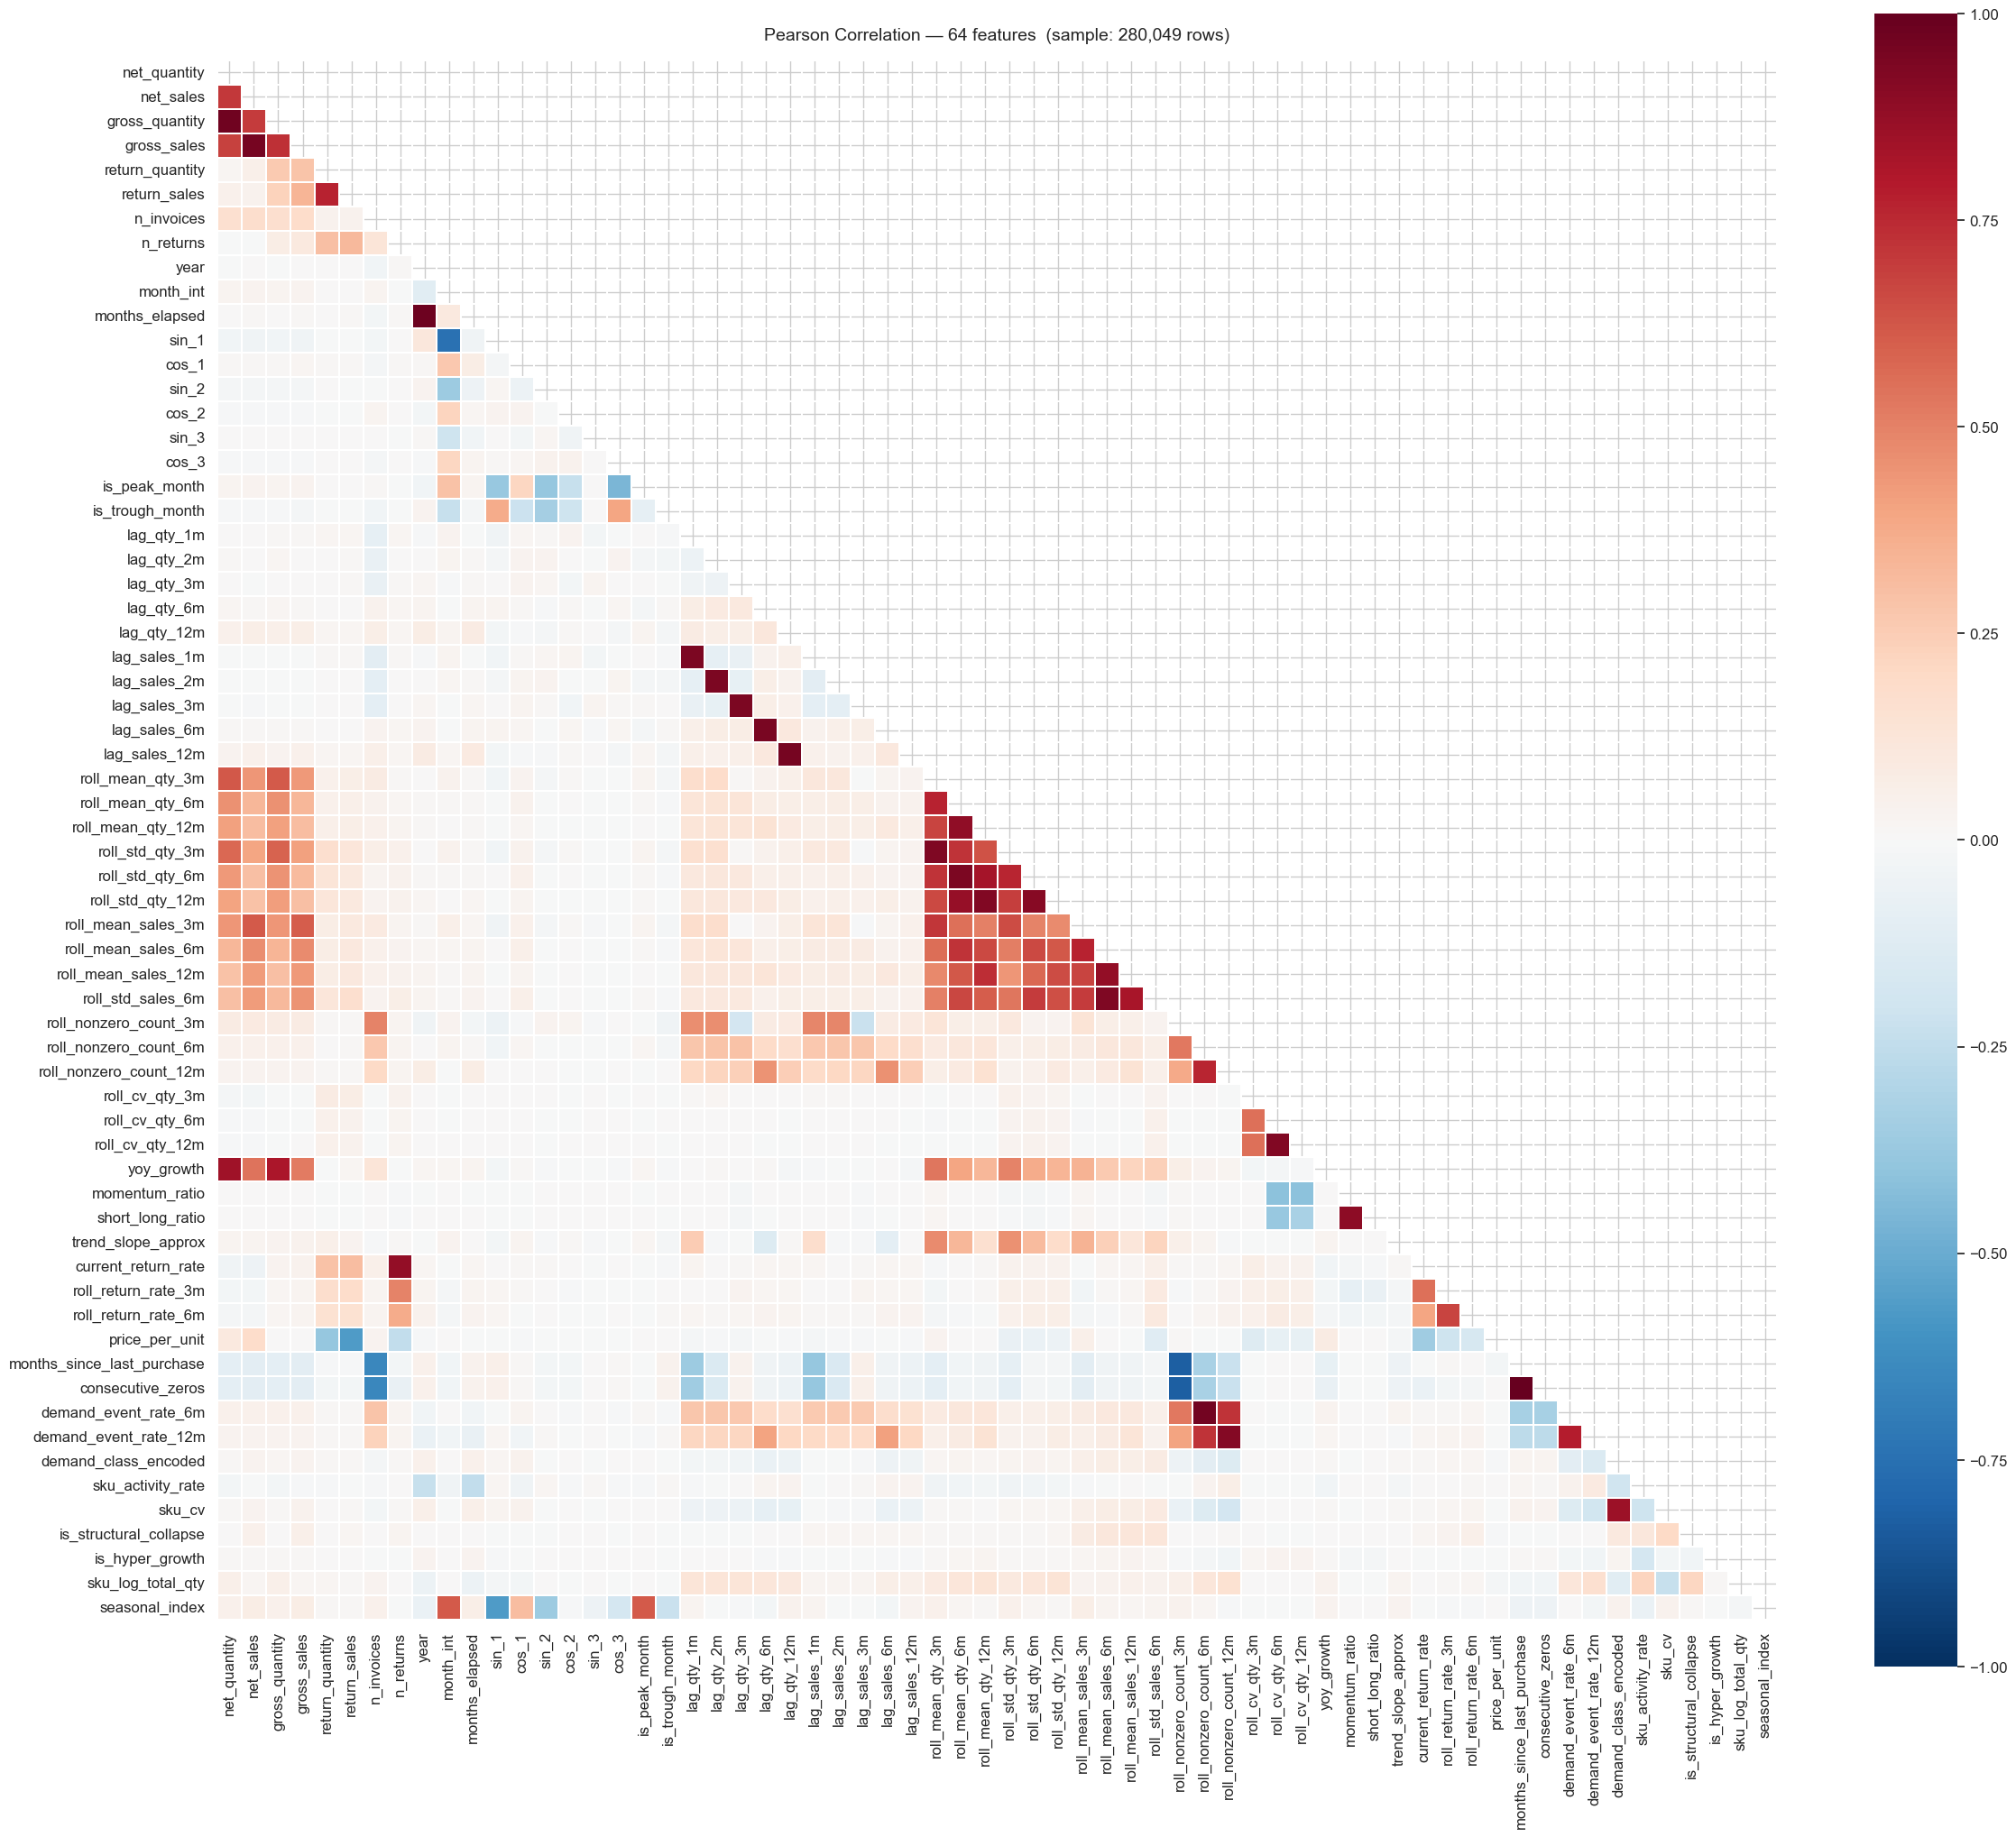

In [12]:
# Full correlation heatmap
n = len(feature_cols)
fs = max(16, n * 0.38)

fig, ax = plt.subplots(figsize=(fs, fs * 0.85))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.3,
    annot=(n <= 30),
    fmt='.2f',
    square=True,
    ax=ax
)
ax.set_title(f'Pearson Correlation — {n} features  (sample: {len(sample_df):,} rows)',
             fontsize=14, pad=16)
plt.tight_layout()
plt.show()

---
## 7. Identify Highly Correlated Pairs

In [17]:
corr_arr = corr_matrix.values
rows_idx, cols_idx = np.where(np.triu(np.abs(corr_arr) >= CORR_THRESHOLD, k=1))

hcp = [
    {
        'feature_a': corr_matrix.columns[r],
        'feature_b': corr_matrix.columns[c],
        'pearson_r': round(float(corr_arr[r, c]), 4)
    }
    for r, c in zip(rows_idx, cols_idx)
]

hcp_df = pd.DataFrame(hcp).sort_values('pearson_r', key=abs, ascending=False)
print(f'Pairs with |r| >= {CORR_THRESHOLD}: {len(hcp_df)}')
hcp_df

Pairs with |r| >= 0.8: 29


,feature_a,feature_b,pearson_r
27,months_since_last_purchase,consecutive_zeros,0.9968
5,year,months_elapsed,0.9768
0,net_quantity,gross_quantity,0.9697
23,roll_nonzero_count_6m,demand_event_rate_6m,0.9624
10,lag_qty_12m,lag_sales_12m,0.9552
2,net_sales,gross_sales,0.9544
9,lag_qty_6m,lag_sales_6m,0.9527
13,roll_mean_qty_6m,roll_std_qty_6m,0.9451
8,lag_qty_3m,lag_sales_3m,0.9402
6,lag_qty_1m,lag_sales_1m,0.9400


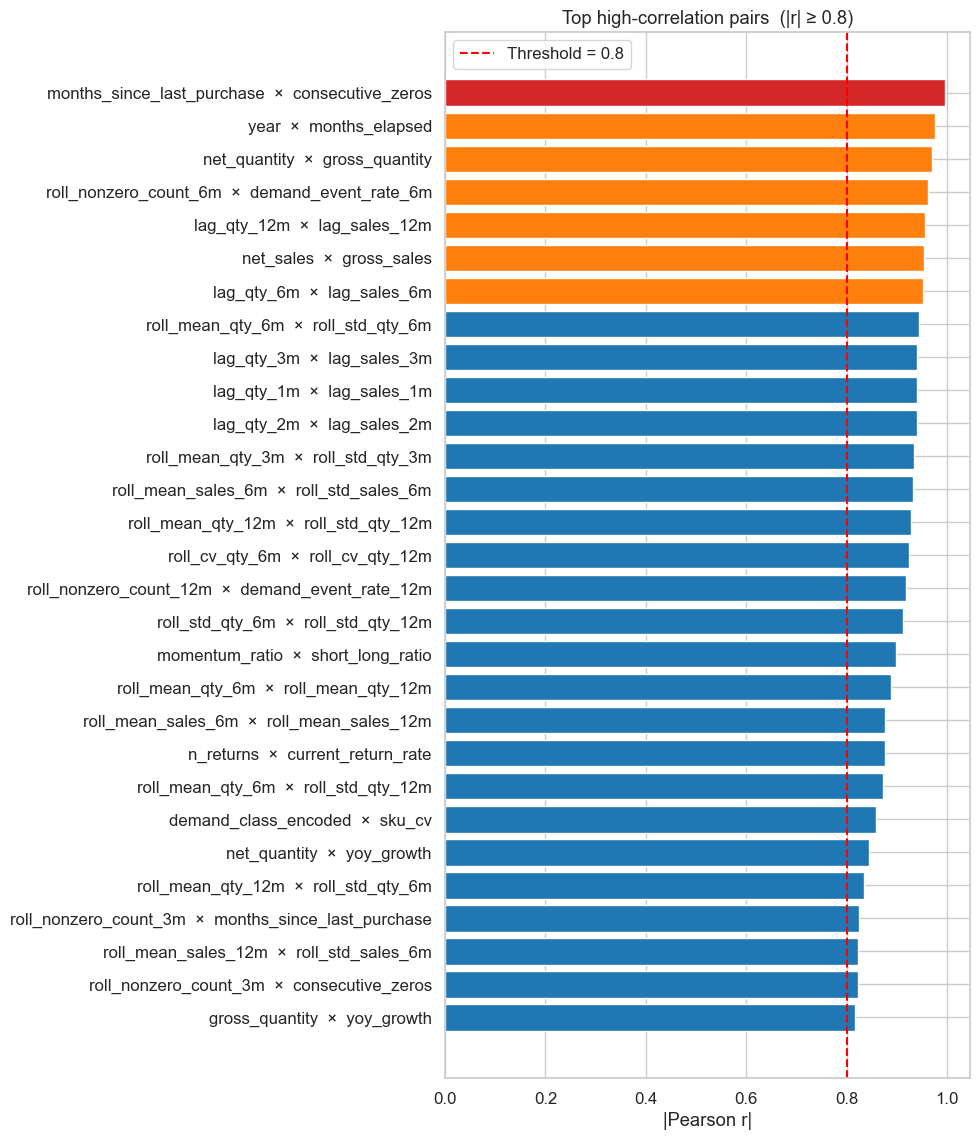

In [18]:
if not hcp_df.empty:
    plot_df = hcp_df.head(30).copy()
    plot_df['pair'] = plot_df['feature_a'] + '  ×  ' + plot_df['feature_b']

    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.40)))
    colors = [
        '#d62728' if abs(r) >= 0.98 else
        '#ff7f0e' if abs(r) >= 0.95 else
        '#1f77b4'
        for r in plot_df['pearson_r']
    ]
    ax.barh(plot_df['pair'].to_list()[::-1],
            plot_df['pearson_r'].abs().to_list()[::-1],
            color=colors[::-1])
    ax.axvline(CORR_THRESHOLD, color='red', linestyle='--', lw=1.5,
               label=f'Threshold = {CORR_THRESHOLD}')
    ax.set_xlabel('|Pearson r|')
    ax.set_title(f'Top high-correlation pairs  (|r| ≥ {CORR_THRESHOLD})')
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 8. Greedy Feature Reduction

**Algorithm:**  
Repeatedly find the feature that participates in the most threshold-violating pairs and drop it,
until no pair exceeds `CORR_THRESHOLD`.  Ties are broken by the highest total correlation burden.

In [20]:
corr_abs       = corr_matrix.abs()
cols_remaining = list(feature_cols)
dropped_cols   = []
drop_reasons   = {}   # col -> list[str] explaining which partner triggered the drop

while True:
    sub = corr_abs.loc[cols_remaining, cols_remaining].copy()
    sub_matrix = sub.values.copy()
    np.fill_diagonal(sub_matrix, 0)

    hi_rows, hi_cols = np.where(np.triu(sub_matrix >= CORR_THRESHOLD, k=1))
    if len(hi_rows) == 0:
        break

    violation_count = {}
    for r, c in zip(hi_rows, hi_cols):
        ca, cb = sub.columns[r], sub.columns[c]
        violation_count[ca] = violation_count.get(ca, 0) + 1
        violation_count[cb] = violation_count.get(cb, 0) + 1

    to_drop = max(violation_count, key=lambda c: (violation_count[c], sub[c].sum()))

    partners = [
        f'{c}  (r={sub.loc[to_drop, c]:.3f})'
        for c in cols_remaining
        if c != to_drop and sub.loc[to_drop, c] >= CORR_THRESHOLD
    ]
    drop_reasons[to_drop] = partners

    dropped_cols.append(to_drop)
    cols_remaining.remove(to_drop)

print(f'Original features  : {len(feature_cols)}')
print(f'Retained features  : {len(cols_remaining)}')
print(f'Dropped features   : {len(dropped_cols)}')

Original features  : 64
Retained features  : 41
Dropped features   : 23


In [21]:
print('\n=== Dropped features (and what they correlated with) ===')
for col in dropped_cols:
    print(f'  [-] {col}')
    for p in drop_reasons.get(col, []):
        print(f'        ↔  {p}')

print('\n=== Retained features ===')
for c in sorted(cols_remaining):
    print(f'  [+] {c}')


=== Dropped features (and what they correlated with) ===
  [-] roll_mean_qty_6m
        ↔  roll_mean_qty_12m  (r=0.888)
        ↔  roll_std_qty_6m  (r=0.945)
        ↔  roll_std_qty_12m  (r=0.873)
  [-] roll_mean_sales_6m
        ↔  roll_mean_sales_12m  (r=0.877)
        ↔  roll_std_sales_6m  (r=0.933)
  [-] roll_std_qty_6m
        ↔  roll_mean_qty_12m  (r=0.835)
        ↔  roll_std_qty_12m  (r=0.912)
  [-] roll_nonzero_count_3m
        ↔  months_since_last_purchase  (r=0.825)
        ↔  consecutive_zeros  (r=0.822)
  [-] gross_quantity
        ↔  net_quantity  (r=0.970)
        ↔  yoy_growth  (r=0.816)
  [-] roll_std_qty_3m
        ↔  roll_mean_qty_3m  (r=0.935)
  [-] demand_event_rate_12m
        ↔  roll_nonzero_count_12m  (r=0.919)
  [-] roll_std_sales_6m
        ↔  roll_mean_sales_12m  (r=0.823)
  [-] roll_nonzero_count_6m
        ↔  demand_event_rate_6m  (r=0.962)
  [-] roll_mean_qty_12m
        ↔  roll_std_qty_12m  (r=0.928)
  [-] gross_sales
        ↔  net_sales  (r=0.954)
  [-

In [26]:
# Verify: max |r| in retained set must be < threshold
sub_final = corr_abs.loc[cols_remaining, cols_remaining].copy()
sub_matrix = sub_final.values.copy()
np.fill_diagonal(sub_matrix, 0)
max_rem = sub_matrix.max()
print(f'Max |r| in retained set: {max_rem:.4f}  (must be < {CORR_THRESHOLD})')
assert max_rem < CORR_THRESHOLD, 'Reduction incomplete — check algorithm'

Max |r| in retained set: 0.7664  (must be < 0.8)


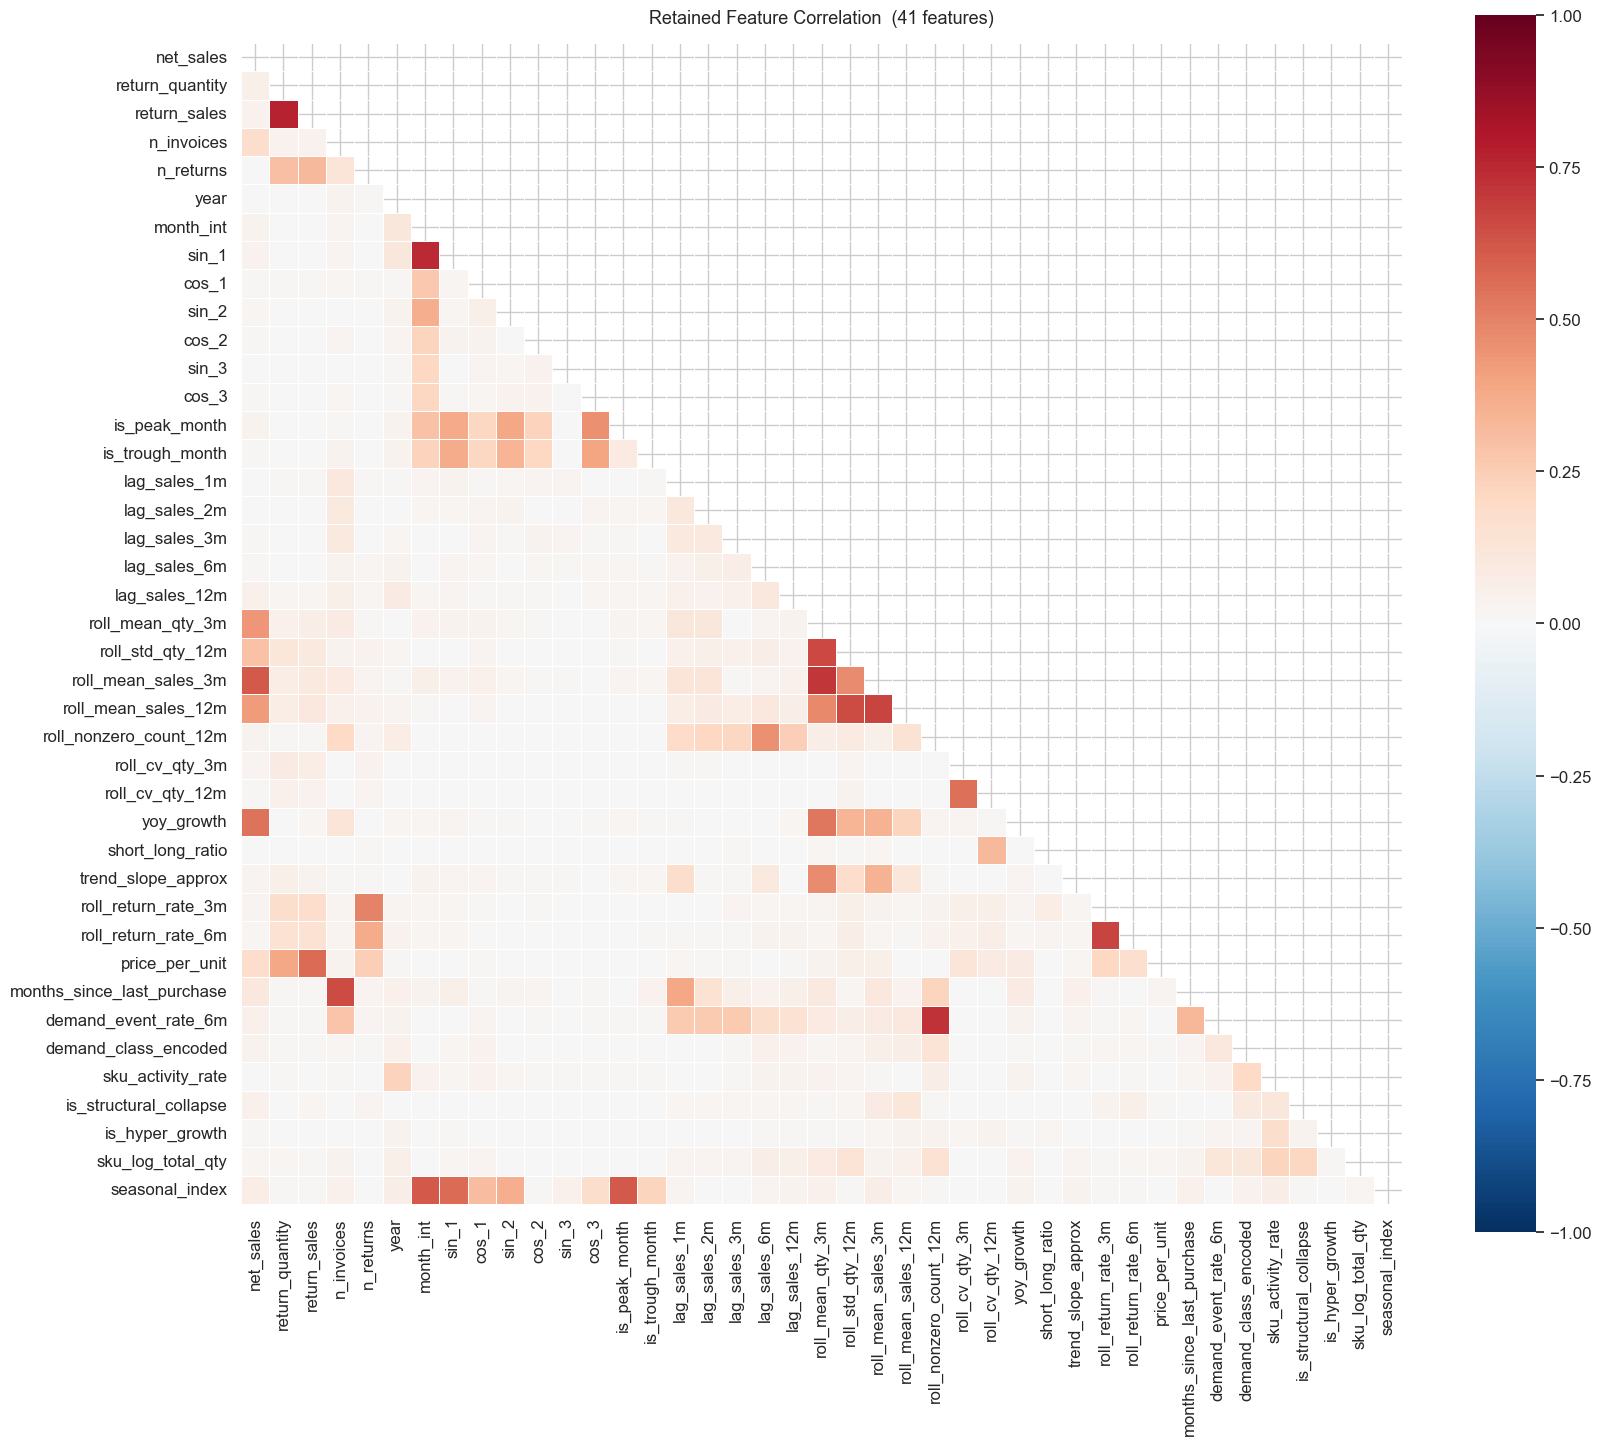

In [27]:
# Heatmap of retained features
n_ret = len(cols_remaining)
fs_r  = max(10, n_ret * 0.42)

fig, ax = plt.subplots(figsize=(fs_r, fs_r * 0.85))
mask_r  = np.triu(np.ones((n_ret, n_ret), dtype=bool))

sns.heatmap(
    sub_final,
    mask=mask_r,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.4,
    annot=(n_ret <= 25),
    fmt='.2f',
    square=True,
    ax=ax
)
ax.set_title(f'Retained Feature Correlation  ({n_ret} features)', fontsize=13, pad=14)
plt.tight_layout()
plt.show()

---
## 9. Distribution Comparison — Dropped vs Retained Pairs

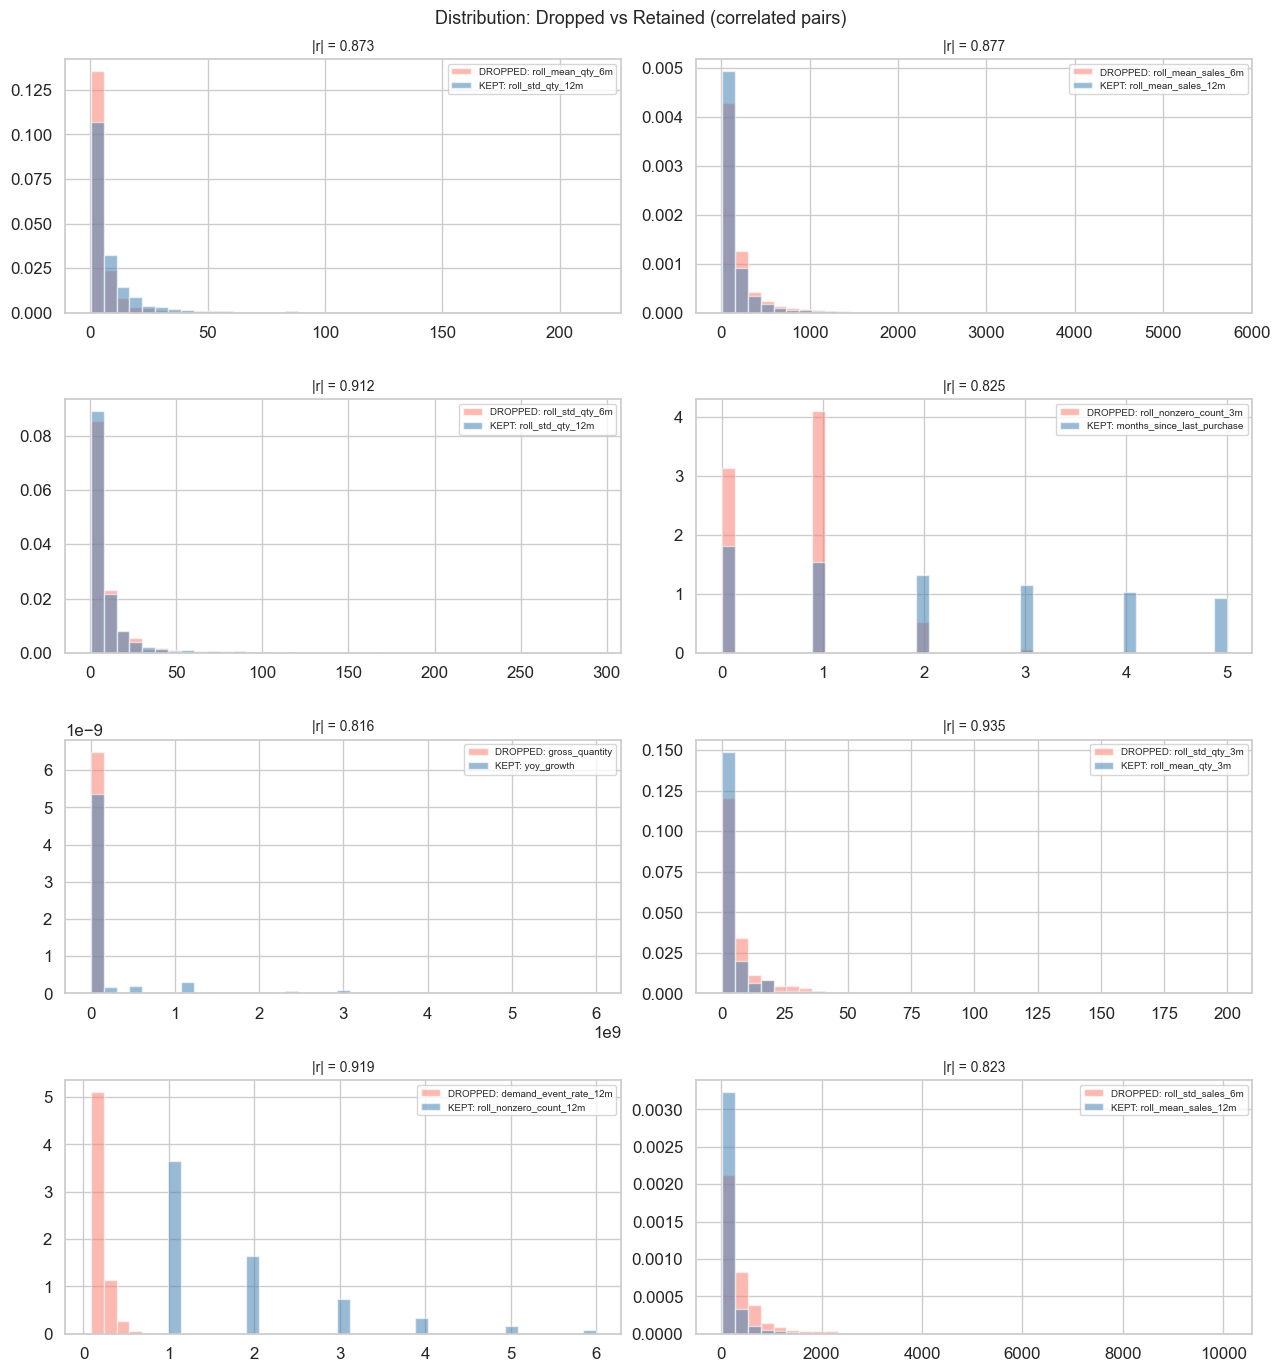

In [28]:
# Map each dropped column to its highest-corr retained partner
drop_to_partner = {}
for col in dropped_cols:
    for reason_str in drop_reasons.get(col, []):
        partner = reason_str.split('  (r=')[0]
        if partner in cols_remaining and col in sample_df.columns:
            drop_to_partner[col] = partner
            break

plot_pairs = list(drop_to_partner.items())[:8]

if plot_pairs:
    ncols_p = 2
    nrows_p = (len(plot_pairs) + 1) // 2
    fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(13, nrows_p * 3.5))
    axes = axes.flatten()

    for i, (drop_col, keep_col) in enumerate(plot_pairs):
        ax = axes[i]
        v_d = sample_df[drop_col].drop_nulls().to_numpy()
        v_k = sample_df[keep_col].drop_nulls().to_numpy() if keep_col in sample_df.columns else np.array([])
        combined = np.concatenate([v_d, v_k]) if len(v_k) else v_d
        lo, hi = np.percentile(combined, 1), np.percentile(combined, 99)
        bins = np.linspace(lo, hi, 40)
        ax.hist(v_d, bins=bins, alpha=0.55, color='salmon',
                label=f'DROPPED: {drop_col}', density=True)
        if len(v_k):
            ax.hist(v_k, bins=bins, alpha=0.55, color='steelblue',
                    label=f'KEPT: {keep_col}', density=True)
        r_val = corr_abs.loc[drop_col, keep_col] if keep_col in corr_abs.columns else 0
        ax.set_title(f'|r| = {r_val:.3f}', fontsize=10)
        ax.legend(fontsize=7)

    for j in range(len(plot_pairs), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Distribution: Dropped vs Retained (correlated pairs)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No drop-partner pairs to visualise (no features were dropped, or no sample overlap).')

---
## 10. Map Reduced Columns to Source Tables

In [29]:
BASE_KEY     = ['outlet_id', 'item_code', 'year_month']
SKU_KEY      = ['item_code']
SEASONAL_KEY = ['item_code', 'month_int']

BASE_FEAT_COLS     = [c for c in lf_base.schema     if c not in BASE_KEY]
ZERO_FEAT_COLS     = [c for c in lf_zero.schema     if c not in BASE_KEY]
TARGET_FEAT_COLS   = [c for c in lf_target.schema   if c not in BASE_KEY]
SKU_FEAT_COLS      = [c for c in lf_sku.schema      if c not in SKU_KEY]
SEASONAL_FEAT_COLS = [c for c in lf_seasonal.schema if c not in SEASONAL_KEY]

dropped_set = set(dropped_cols)

base_drop     = [c for c in BASE_FEAT_COLS     if c in dropped_set]
zero_drop     = [c for c in ZERO_FEAT_COLS     if c in dropped_set]
sku_drop      = [c for c in SKU_FEAT_COLS      if c in dropped_set]
seasonal_drop = [c for c in SEASONAL_FEAT_COLS if c in dropped_set]

print(f'base_features    : drop {len(base_drop):>2} cols → {base_drop or "none"}')
print(f'zero_inflation   : drop {len(zero_drop):>2} cols → {zero_drop or "none"}')
print(f'enriched_sku     : drop {len(sku_drop):>2} cols → {sku_drop or "none"}')
print(f'seasonal_index   : drop {len(seasonal_drop):>2} cols → {seasonal_drop or "none"}')
print(f'target_features  : 0 drops  (targets always retained)')

base_features    : drop 20 cols → ['net_quantity', 'gross_quantity', 'gross_sales', 'months_elapsed', 'lag_qty_1m', 'lag_qty_2m', 'lag_qty_3m', 'lag_qty_6m', 'lag_qty_12m', 'roll_mean_qty_6m', 'roll_mean_qty_12m', 'roll_std_qty_3m', 'roll_std_qty_6m', 'roll_mean_sales_6m', 'roll_std_sales_6m', 'roll_nonzero_count_3m', 'roll_nonzero_count_6m', 'roll_cv_qty_6m', 'momentum_ratio', 'current_return_rate']
zero_inflation   : drop  2 cols → ['consecutive_zeros', 'demand_event_rate_12m']
enriched_sku     : drop  1 cols → ['sku_cv']
seasonal_index   : drop  0 cols → none
target_features  : 0 drops  (targets always retained)


---
## 11. Save Reduced Feature Tables

Each time-series table is:
- **Row-filtered** using the `demand_event_rate_6m > 0` criterion (via semi-join on active rows)
- **Column-reduced** (correlated columns removed)

Lookup tables (SKU, seasonal) are column-reduced only.

In [30]:
# Collect the set of (outlet_id, item_code, year_month) that survive the activity filter
# Use it as a semi-join key for the other time-series tables.
active_keys = (
    lf_base_active
    .select(JOIN_KEYS)
    .collect()
)
print(f'Active (outlet_id, item_code, year_month) keys: {len(active_keys):,}')

Active (outlet_id, item_code, year_month) keys: 23,442,722


In [31]:
def write_reduced_ts(lf: pl.LazyFrame,
                     drop_cols: list,
                     output_path: Path,
                     active_keys_lf: pl.LazyFrame) -> None:
    """Filter to active rows, drop correlated cols, write parquet."""
    lf_out = (
        lf
        .join(active_keys_lf, on=JOIN_KEYS, how='semi')
    )
    if drop_cols:
        lf_out = lf_out.drop(drop_cols)
    lf_out.collect().write_parquet(output_path)
    print(f'  {output_path.name}')

def write_reduced_lookup(lf: pl.LazyFrame,
                         drop_cols: list,
                         output_path: Path) -> None:
    """Column-reduce a lookup table and write parquet."""
    lf_out = lf.drop(drop_cols) if drop_cols else lf
    lf_out.collect().write_parquet(output_path)
    print(f'  {output_path.name}')


active_keys_lf = active_keys.lazy()
print('Writing reduced tables...')

write_reduced_ts(
    lf_base, base_drop,
    OUTPUT_DIR / 'base_features_reduced.parquet',
    active_keys_lf
)

write_reduced_ts(
    lf_zero, zero_drop,
    OUTPUT_DIR / 'zero_inflation_features_reduced.parquet',
    active_keys_lf
)

write_reduced_ts(
    lf_target, [],          # targets are never dropped
    OUTPUT_DIR / 'target_features_reduced.parquet',
    active_keys_lf
)

write_reduced_lookup(
    lf_sku, sku_drop,
    OUTPUT_DIR / 'enriched_sku_lookup_reduced.parquet'
)

write_reduced_lookup(
    lf_seasonal, seasonal_drop,
    OUTPUT_DIR / 'seasonal_index_lookup_reduced.parquet'
)

print('Done.')

Writing reduced tables...
  base_features_reduced.parquet
  zero_inflation_features_reduced.parquet
  target_features_reduced.parquet
  enriched_sku_lookup_reduced.parquet
  seasonal_index_lookup_reduced.parquet
Done.


---
## 12. Validation

In [32]:
output_files = [
    'base_features_reduced.parquet',
    'zero_inflation_features_reduced.parquet',
    'target_features_reduced.parquet',
    'enriched_sku_lookup_reduced.parquet',
    'seasonal_index_lookup_reduced.parquet',
]

print(f'{"File":<50} {"Rows":>12} {"Cols":>6} {"Size MB":>9}')
print('-' * 82)
for fname in output_files:
    fp = OUTPUT_DIR / fname
    if fp.exists():
        df_v = pl.read_parquet(fp)
        mb   = fp.stat().st_size / 1_048_576
        print(f'{fname:<50} {df_v.shape[0]:>12,} {df_v.shape[1]:>6} {mb:>9.1f}')
    else:
        print(f'{fname:<50}  NOT FOUND')

File                                                       Rows   Cols   Size MB
----------------------------------------------------------------------------------
base_features_reduced.parquet                        23,442,722     44     407.1
zero_inflation_features_reduced.parquet              23,442,722      5      19.3
target_features_reduced.parquet                      23,442,722      7      36.6
enriched_sku_lookup_reduced.parquet                          50      7       0.0
seasonal_index_lookup_reduced.parquet                       600      3       0.0


In [33]:
# End-to-end join smoke-test — collect 5 rows to validate schema integrity
lf_b_r = pl.scan_parquet(OUTPUT_DIR / 'base_features_reduced.parquet')
lf_z_r = pl.scan_parquet(OUTPUT_DIR / 'zero_inflation_features_reduced.parquet')
lf_t_r = pl.scan_parquet(OUTPUT_DIR / 'target_features_reduced.parquet')
lf_s_r = pl.scan_parquet(OUTPUT_DIR / 'enriched_sku_lookup_reduced.parquet')
lf_se_r= pl.scan_parquet(OUTPUT_DIR / 'seasonal_index_lookup_reduced.parquet')

preview = (
    lf_b_r
    .join(lf_z_r,  on=JOIN_KEYS,                   how='left')
    .join(lf_t_r,  on=JOIN_KEYS,                   how='left')
    .join(lf_s_r,  on='item_code',                 how='left')
    .join(lf_se_r, on=['item_code', 'month_int'],  how='left')
    .limit(5)
    .collect()
)

print(f'Joined reduced matrix: {preview.shape[1]} columns')
preview

Joined reduced matrix: 57 columns


outlet_id,item_code,year_month,net_sales,return_quantity,return_sales,n_invoices,n_returns,territory_id,region,district,province,product_category,product_line,brand,cluster_definition,year,month_int,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3,is_peak_month,is_trough_month,lag_sales_1m,lag_sales_2m,lag_sales_3m,lag_sales_6m,lag_sales_12m,roll_mean_qty_3m,roll_std_qty_12m,roll_mean_sales_3m,roll_mean_sales_12m,roll_nonzero_count_12m,roll_cv_qty_3m,roll_cv_qty_12m,yoy_growth,short_long_ratio,trend_slope_approx,roll_return_rate_3m,roll_return_rate_6m,price_per_unit,months_since_last_purchase,demand_event_rate_6m,target_qty_raw,target_qty_log1p,target_is_nonzero,target_log1p_net_sales,demand_class,demand_class_encoded,sku_activity_rate,is_structural_collapse,is_hyper_growth,sku_log_total_qty,seasonal_index
str,str,str,f64,i64,f64,u32,u32,str,str,str,str,str,str,str,str,i32,i32,f64,f64,f64,f64,f64,f64,i8,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,i64,f64,i8,f64,str,i8,f64,i8,i8,f64,f64
"""0""","""gf1000203""","""2015-10""",6772.5,0,0.0,1,0,"""24""","""region_6""","""district_3""","""province_3""","""cat_5""","""prod_line15""","""brand_1""","""Power""",2015,10,-0.866025,0.5,-0.866025,-0.5,2.3887e-15,-1.0,1,0,0.0,0.0,0.0,0.0,null,50.0,47.434165,2257.5,677.25,1,1.732051,3.162278,null,3.333333,0.0,0.0,0.0,45.15,0,0.166667,0,0.0,0,0.0,"""Continuous""",0,1.0,0,0,14.53719,1.519578
"""0""","""gf1000203""","""2015-11""",0.0,0,0.0,0,0,"""24""","""region_6""","""district_3""","""province_3""","""cat_5""","""prod_line15""","""brand_1""","""Power""",2015,11,-0.5,0.866025,-0.866025,0.5,-1.0,-2.4499e-15,0,0,8.820773,0.0,0.0,0.0,null,50.0,45.226702,2257.5,615.681818,1,1.732051,3.316625,null,3.666667,30.0,0.0,0.0,0.0,1,0.166667,0,0.0,0,0.0,"""Continuous""",0,1.0,0,0,14.53719,1.123569
"""0""","""gf1000203""","""2015-12""",0.0,0,0.0,0,0,"""24""","""region_6""","""district_3""","""province_3""","""cat_5""","""prod_line15""","""brand_1""","""Power""",2015,12,-2.4493e-16,1.0,-4.8986e-16,1.0,-7.3479e-16,1.0,0,0,0.0,8.820773,0.0,0.0,null,50.0,43.30127,2257.5,564.375,1,1.732051,3.464102,null,4.0,0.0,0.0,0.0,0.0,2,0.166667,0,0.0,0,0.0,"""Continuous""",0,1.0,0,0,14.53719,1.056841
"""0""","""gf1000203""","""2016-01""",0.0,0,0.0,0,0,"""24""","""region_6""","""district_3""","""province_3""","""cat_5""","""prod_line15""","""brand_1""","""Power""",2016,1,0.5,0.866025,0.866025,0.5,1.0,6.1232e-17,0,0,0.0,0.0,8.820773,0.0,0.0,0.0,43.30127,0.0,564.375,1,0.0,3.464102,0.0,0.0,0.0,0.0,0.0,0.0,3,0.166667,0,0.0,0,0.0,"""Continuous""",0,1.0,0,0,14.53719,0.904575
"""0""","""gf1000203""","""2016-02""",0.0,0,0.0,0,0,"""24""","""region_6""","""district_3""","""province_3""","""cat_5""","""prod_line15""","""brand_1""","""Power""",2016,2,0.866025,0.5,0.866025,-0.5,1.2246e-16,-1.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,43.30127,0.0,564.375,1,0.0,3.464102,0.0,0.0,0.0,0.0,0.0,0.0,4,0.166667,0,0.0,0,0.0,"""Continuous""",0,1.0,0,0,14.53719,0.850324


In [34]:
# Feature count summary
print('=== Feature reduction summary ===')
rows = [
    ('base_features',   len(BASE_FEAT_COLS),     len(base_drop)),
    ('zero_inflation',  len(ZERO_FEAT_COLS),     len(zero_drop)),
    ('target_features', len(TARGET_FEAT_COLS),   0),
    ('enriched_sku',    len(SKU_FEAT_COLS),      len(sku_drop)),
    ('seasonal_index',  len(SEASONAL_FEAT_COLS), len(seasonal_drop)),
]
total_b = total_a = 0
for tbl, before, removed in rows:
    after = before - removed
    total_b += before
    total_a += after
    print(f'  {tbl:<30}  {before:>3} → {after:>3}  (removed {removed})')
print(f'  {"TOTAL (feature cols)":<30}  {total_b:>3} → {total_a:>3}  (removed {total_b - total_a})')
print()
print(f'  Corr threshold    : |r| >= {CORR_THRESHOLD}')
print(f'  Activity filter   : demand_event_rate_6m > 0  (row-level, prior 6-month window)')
print(f'  Row count before  : {n_before:,}')
print(f'  Row count after   : {n_after:,}  ({n_after/n_before:.1%} retained)')

=== Feature reduction summary ===
  base_features                    61 →  41  (removed 20)
  zero_inflation                    4 →   2  (removed 2)
  target_features                   4 →   4  (removed 0)
  enriched_sku                      7 →   6  (removed 1)
  seasonal_index                    1 →   1  (removed 0)
  TOTAL (feature cols)             77 →  54  (removed 23)

  Corr threshold    : |r| >= 0.8
  Activity filter   : demand_event_rate_6m > 0  (row-level, prior 6-month window)
  Row count before  : 100,618,320
  Row count after   : 23,442,722  (23.3% retained)


---
## 13. Summary

| Step | What | Outcome |
|---|---|---|
| **Activity filter** | Drop rows where `demand_event_rate_6m == 0` | Removes dormant time-points across the full history |
| **Correlation filter** | Greedy elimination at \|r\| ≥ 0.90 | Single representative per correlated group |
| **Output** | 5× `*_reduced.parquet` in `data/Intermediate/` | Ready for per-cluster XGBoost training |

**Next:** join the reduced tables via `load_training_matrix()` (see `docs/11_feature_merging_guide.md`)
pointed at the `*_reduced.parquet` files, then split on `cluster_definition` before fitting.

In [35]:
# Save the full reduced modeling matrix (joined)
full_reduced_matrix = (
    lf_b_r
    .join(lf_z_r,  on=JOIN_KEYS,                   how='left')
    .join(lf_t_r,  on=JOIN_KEYS,                   how='left')
    .join(lf_s_r,  on='item_code',                 how='left')
    .join(lf_se_r, on=['item_code', 'month_int'],  how='left')
    .collect()
)

full_reduced_matrix.write_parquet(OUTPUT_DIR / 'full_reduced_modeling_matrix.parquet')
print(f'Saved full reduced matrix: {full_reduced_matrix.shape[0]:,} rows, {full_reduced_matrix.shape[1]} columns')

Saved full reduced matrix: 23,442,722 rows, 57 columns
